In [1]:
import xarray as xr
import intake
from shapely.geometry import Polygon, Point
import regionmask

eerie_cat = intake.open_catalog("https://raw.githubusercontent.com/eerie-project/intake_catalogues/main/eerie.yaml")

In [2]:
ne_corner = (-81.152, -5.892)
nw_corner = (-86.624, -8.855)
sw_corner = (-81.987, -17.148)
se_corner = (-76.285, -14.042)

corners = [ne_corner, nw_corner, sw_corner, se_corner]
polygon = Polygon(corners)

In [ ]:
ds_esa_cci_sst = eerie_cat["dkrz.disk.observations.ESA-CCI-SST.kerchunk"].to_dask()
esa_cci_mask = regionmask.Regions([polygon]).mask(ds_esa_cci_sst["lon"], ds_esa_cci_sst["lat"])

In [ ]:
esa_cci_mask.to_netcdf("/work/mh0256/m301014/coastal-upwelling-proj/data/interim/region_masks/esa-cci-sst_peru_mask.nc")

In [ ]:
ds_era5_sst = eerie_cat["dkrz.disk.observations.ERA5.era5-dkrz.surface_analysis_daily"].to_dask()
era5_mask = regionmask.Regions([polygon]).mask(ds_era5_sst["lon"], ds_era5_sst["lat"])
era5_mask = xr.where(era5_mask.isnull(), 0, 1)
era5_mask.to_netcdf("/work/mh0256/m301014/coastal-upwelling-proj/data/interim/region_masks/era5_sst_peru_mask.nc")

In [3]:
ds_era5_stress = xr.open_dataset(
    "/work/mh0256/m301014/coastal-upwelling-proj/data/raw/ERA5/era5_gr1_mm_stress.nc"
)

era5_mask = regionmask.Regions([polygon]).mask(ds_era5_stress["longitude"], ds_era5_stress["latitude"])
era5_mask = xr.where(era5_mask.isnull(), 0, 1)
# era5_mask.to_netcdf("/work/mh0256/m301014/coastal-upwelling-proj/data/interim/region_masks/era5_stress_peru_mask.nc")


In [4]:
ds_era5_stress

<xarray.Dataset> Size: 8GB
Dimensions:     (valid_time: 912, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 7kB 1950-01-01T06:00:00 ... 2025-...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B 0
    expver      (valid_time) <U4 15kB ...
Data variables:
    avg_iews    (valid_time, latitude, longitude) float32 4GB ...
    avg_inss    (valid_time, latitude, longitude) float32 4GB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-01-30T09:06 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
ds_en4_sst = eerie_cat["dkrz.disk.observations.EN4.en4.monthly"].to_dask()
en4_mask = regionmask.Regions([polygon]).mask(ds_en4_sst["lon"], ds_en4_sst["lat"])
en4_mask = xr.where(en4_mask.isnull(), 0, 1)
en4_mask.to_netcdf("/work/mh0256/m301014/coastal-upwelling-proj/data/interim/region_masks/en4_sst_peru_mask.nc")

In [ ]:
ds_HadISST = xr.open_dataset("/work/mh0256/m301014/coastal-upwelling-proj/data/raw/HadISST/HadISST_sst.nc.gz")
HadISST_mask = regionmask.Regions([polygon]).mask(ds_HadISST["longitude"], ds_HadISST["latitude"])
HadISST_mask = xr.where(HadISST_mask.isnull(), 0, 1)
HadISST_mask.to_netcdf("/work/mh0256/m301014/coastal-upwelling-proj/data/interim/region_masks/HadISST_peru_mask.nc")

In [13]:
import numpy as np
ds_atm_mm_gn_hist = eerie_cat["dkrz.disk.model-output.icon-esm-er.hist-1950.v20240618.atmos.native.2d_monthly_mean"].to_dask()
icon_atm_mask = regionmask.Regions([polygon]).mask(ds_atm_mm_gn_hist["lon"], ds_atm_mm_gn_hist["lat"])
icon_atm_mask = xr.where(icon_atm_mask.isnull(), 0, 1)
icon_atm_mask.to_netcdf("/work/mh0256/m301014/coastal-upwelling-proj/data/interim/region_masks/icon_atm_peru_mask.nc")

/home/m/m301014/.conda/envs/age-tracer/lib/python3.11/site-packages/regionmask/core/mask.py:184: UserWarning: lon or lat is given as 'radian' (see the 'units' attrs). Should they be converted to degree?
  warnings.warn(


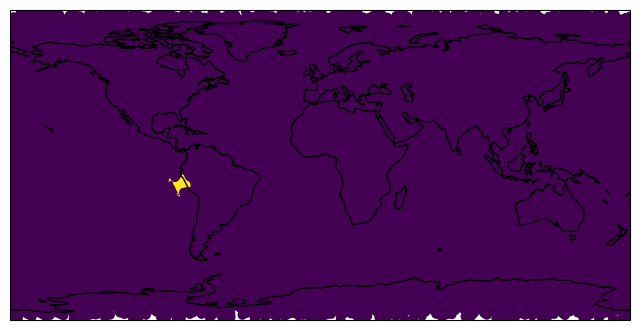

In [12]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={"projection": ccrs.PlateCarree()})

ax.scatter(
    icon_atm_mask["lon"].values[::50],
    icon_atm_mask["lat"].values[::50],
    c=icon_atm_mask.values[::50],
    transform=ccrs.PlateCarree(),
)
ax.coastlines(transform=ccrs.PlateCarree())
